In [9]:
import pandas as pd

df = pd.read_csv("/content/customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].dtype

dtype('float64')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
churn_rate

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
df.groupby("gender")["Churn"].value_counts()

gender  Churn
Female  No       2549
        Yes       939
Male    No       2625
        Yes       930
Name: count, dtype: int64

In [ ]:
df.groupby("Contract")["Churn"].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [ ]:
contract_churn_rate = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

In [ ]:
contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

In [ ]:
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [ ]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

In [ ]:
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
tenure_churn = pd.cut(
      df["tenure"],
      bins=[0, 12, 24, 48, 72],
      labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
              )

pd.crosstab(tenure_churn, df["Churn"],
normalize="index") * 100


Churn,No,Yes
tenure,,
0-12 months,52.321839,47.678161
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


In [ ]:
df.groupby("Churn")["MonthlyCharges"].median()

,MonthlyCharges
Churn,
No,64.425
Yes,79.650


In [ ]:
df.groupby("Churn")["TotalCharges"].mean()

,TotalCharges
Churn,
No,2552.882494
Yes,1531.796094


In [ ]:
df.groupby("Churn")["TotalCharges"].median()

,TotalCharges
Churn,
No,1679.525
Yes,703.550


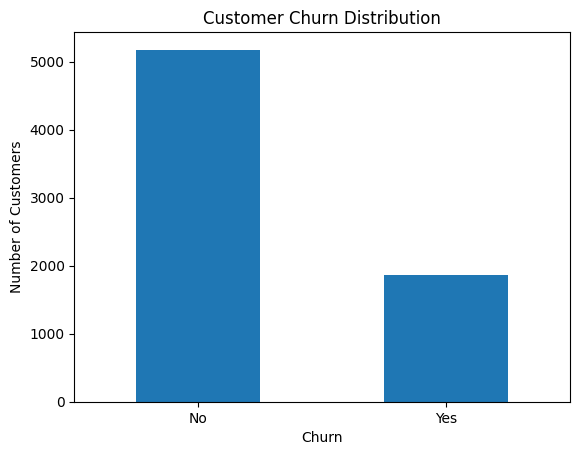

In [ ]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

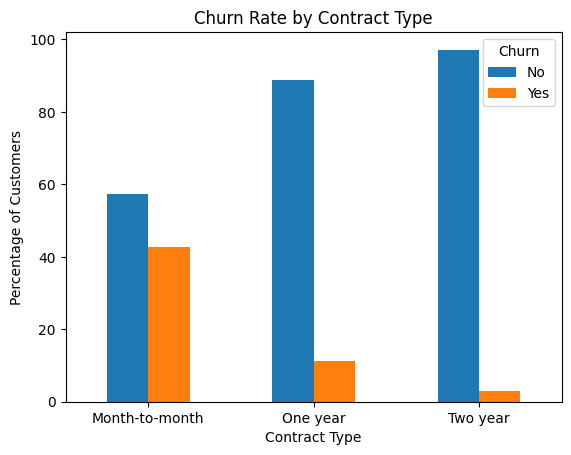

In [ ]:
contract_churn = pd.crosstab(
      df["Contract"],
          df["Churn"],
              normalize="index"
              ) * 100

contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


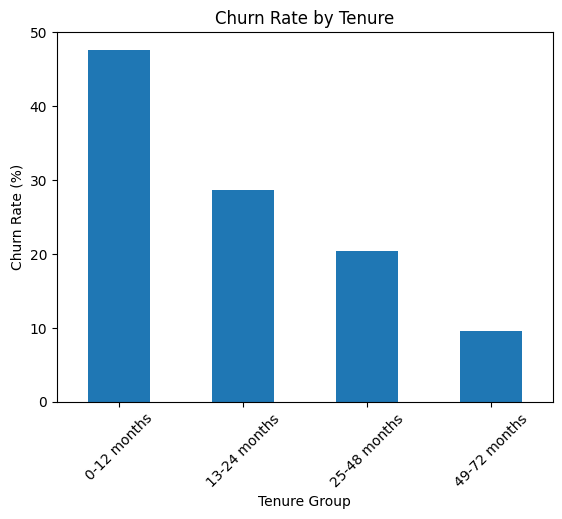

In [ ]:
tenure_churn = pd.crosstab(
      tenure_churn,
          df["Churn"],
              normalize="index"
              ) * 100

tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

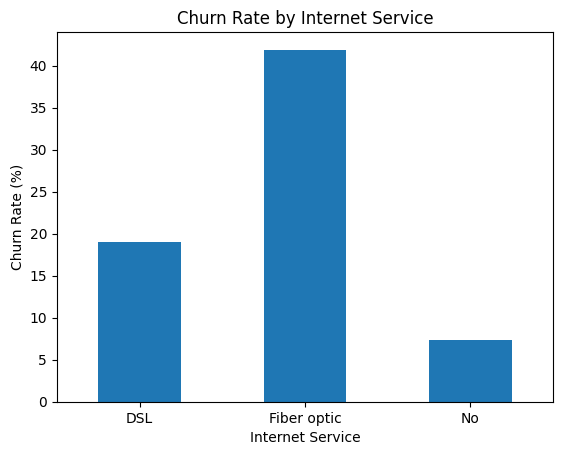

In [ ]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

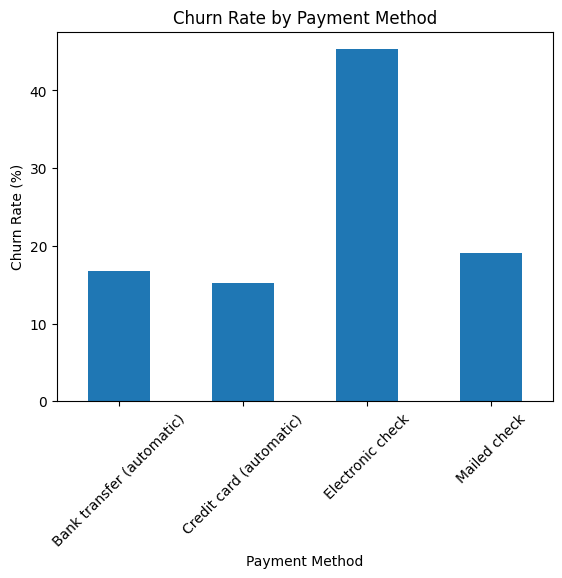

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


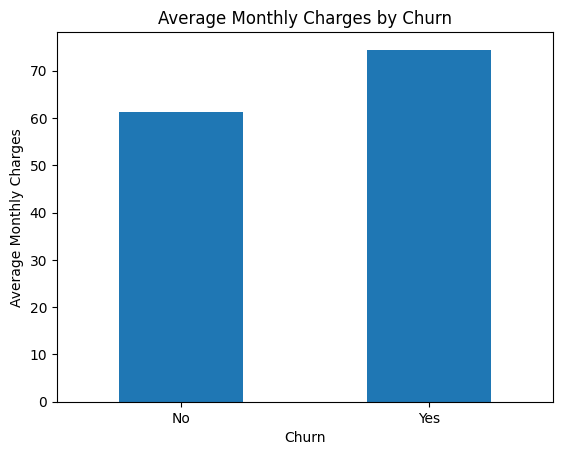

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar")

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

In [ ]:
senior_churn = pd.crosstab(
      df["SeniorCitizen"],
          df["Churn"],
              normalize="index"
              ) * 100

senior_churn


Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


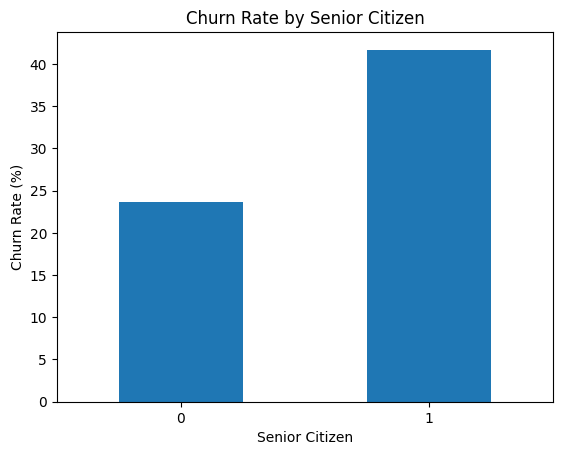

In [ ]:
senior_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
partner_churn = pd.crosstab(
      df["Partner"],
          df["Churn"],
              normalize="index"
              ) * 100

partner_churn


Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


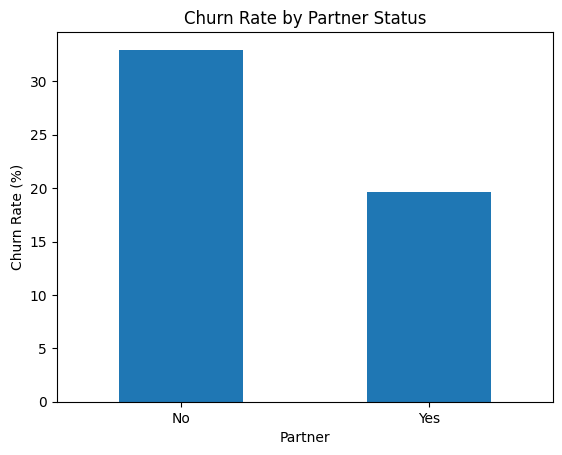

In [ ]:
partner_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
dependent_churn = pd.crosstab(
      df["Dependents"],
          df["Churn"],
              normalize="index"
              ) * 100

dependent_churn


Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


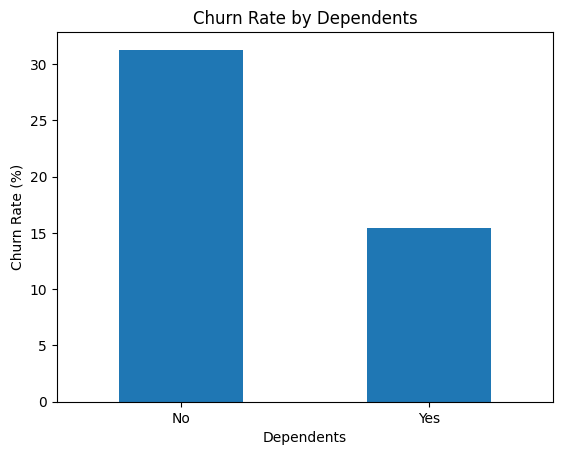

In [ ]:
dependent_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
phone_churn = pd.crosstab(
      df["PhoneService"],
          df["Churn"],
              normalize="index"
              ) * 100

phone_churn


Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


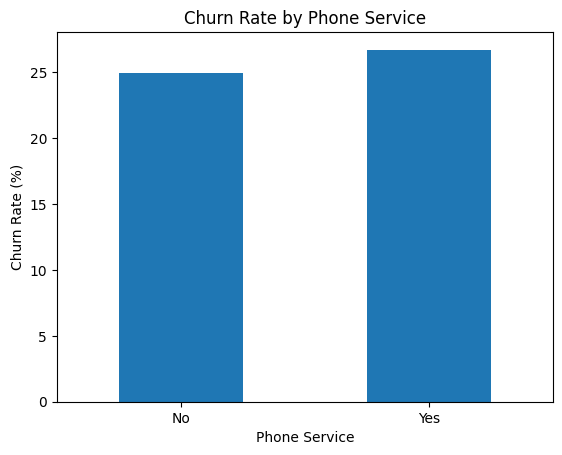

In [ ]:
phone_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
security_churn = pd.crosstab(
      df["OnlineSecurity"],
          df["Churn"],
              normalize="index"
              ) * 100

security_churn


Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


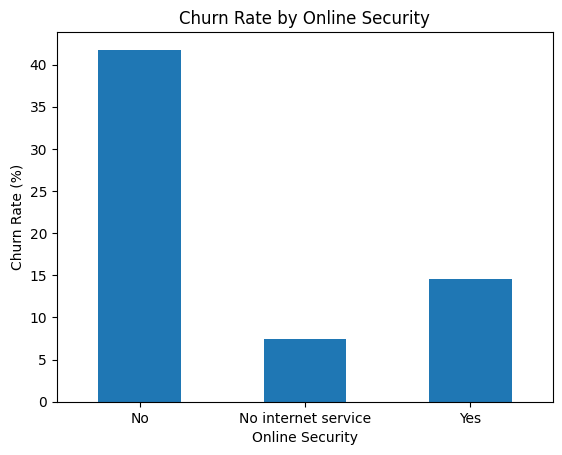

In [ ]:
security_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
backup_churn = pd.crosstab(
      df["OnlineBackup"],
          df["Churn"],
              normalize="index"
              ) * 100

backup_churn


Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


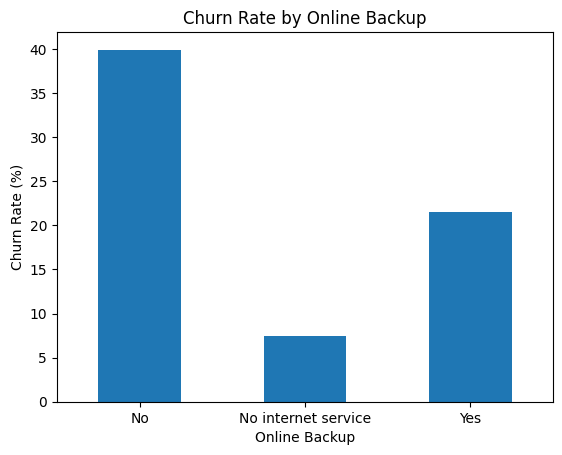

In [ ]:
backup_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
device_churn = pd.crosstab(
      df["DeviceProtection"],
          df["Churn"],
              normalize="index"
              ) * 100

device_churn


Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


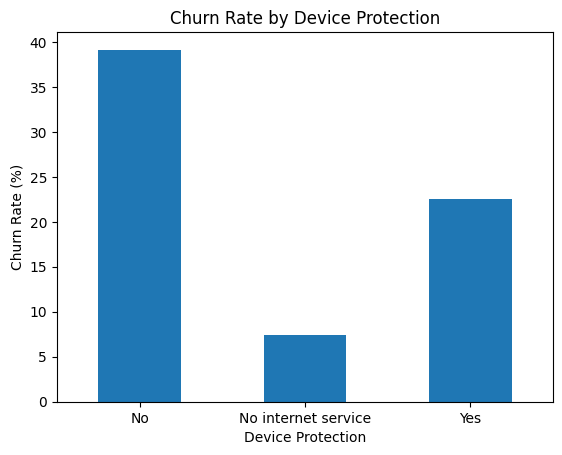

In [ ]:
device_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
tech_churn = pd.crosstab(
      df["TechSupport"],
          df["Churn"],
              normalize="index"
              ) * 100

tech_churn


Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


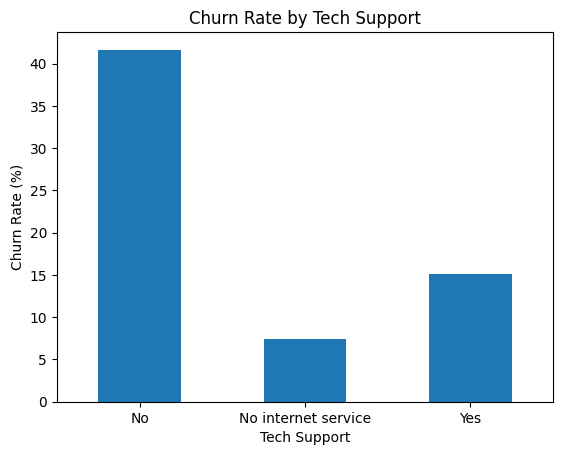

In [ ]:
tech_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
streamingtv_churn = pd.crosstab(
      df["StreamingTV"],
          df["Churn"],
              normalize="index"
              ) * 100

streamingtv_churn


Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


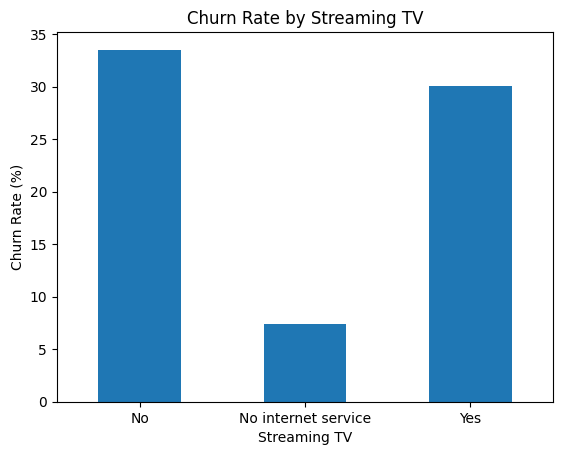

In [ ]:
streamingtv_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
streamingmovies_churn = pd.crosstab(
      df["StreamingMovies"],
          df["Churn"],
              normalize="index"
              ) * 100

streamingmovies_churn


Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


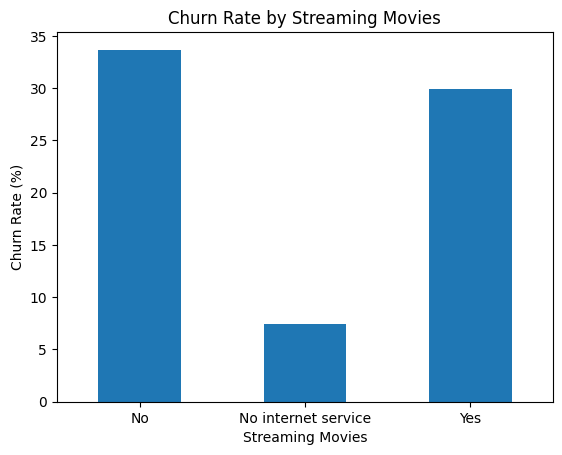

In [ ]:
streamingmovies_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
paperless_churn = pd.crosstab(
      df["PaperlessBilling"],
          df["Churn"],
              normalize="index"
              ) * 100

paperless_churn


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


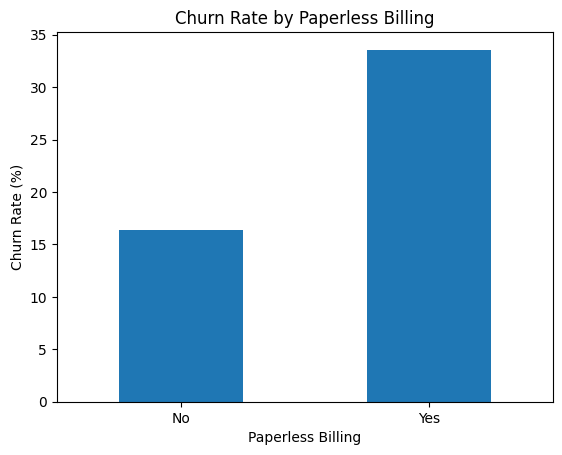

In [ ]:
paperless_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [11]:
multiplelines_churn = pd.crosstab(
      df["MultipleLines"],
          df["Churn"],
              normalize="index"
              ) * 100

multiplelines_churn


Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


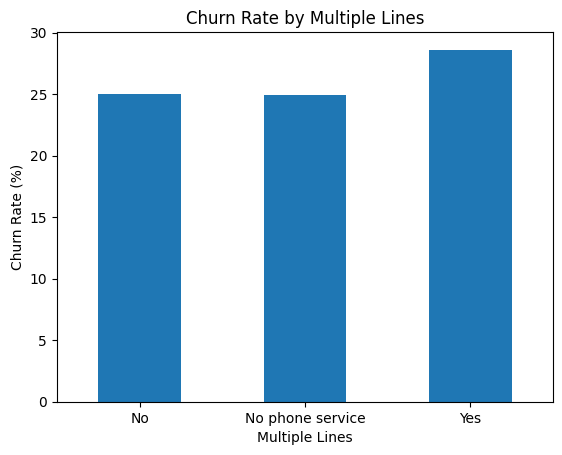

In [12]:
multiplelines_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [13]:
security_churn = pd.crosstab(
      df["OnlineSecurity"],
          df["Churn"],
              normalize="index"
              ) * 100

security_churn


Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


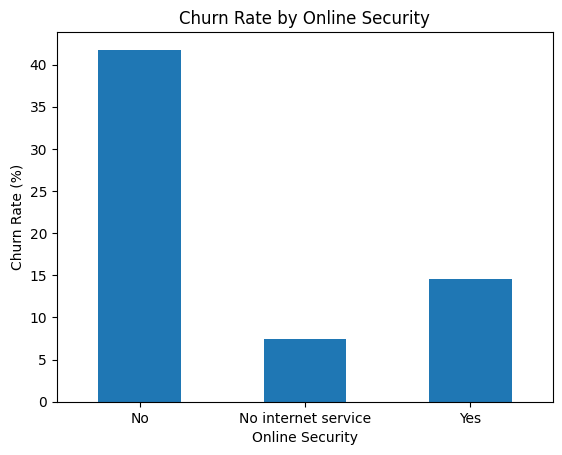

In [14]:
security_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [15]:
backup_churn = pd.crosstab(
      df["OnlineBackup"],
          df["Churn"],
              normalize="index"
              ) * 100

backup_churn


Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


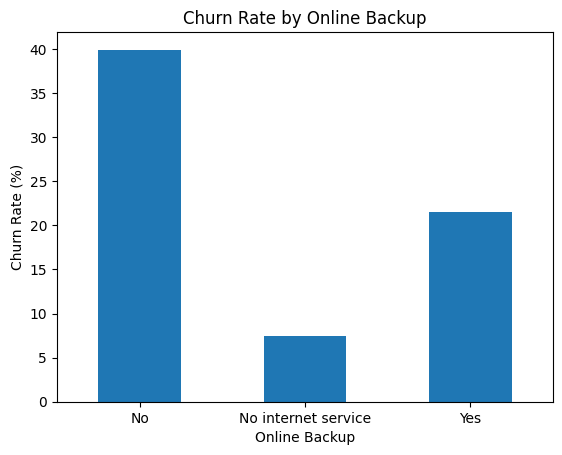

In [16]:
backup_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [17]:
device_churn = pd.crosstab(
      df["DeviceProtection"],
          df["Churn"],
              normalize="index"
              ) * 100

device_churn


Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


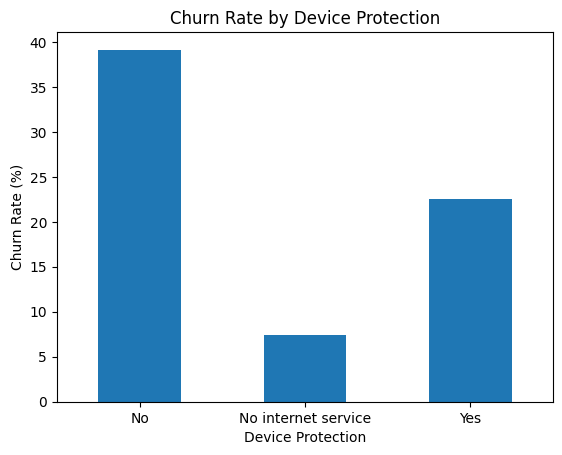

In [18]:
device_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [20]:
tech_churn = pd.crosstab(
      df["TechSupport"],
          df["Churn"],
              normalize="index"
              ) * 100

tech_churn


Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


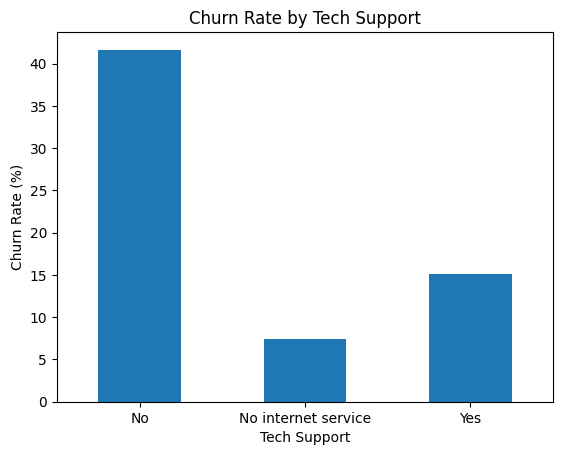

In [21]:
tech_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [22]:
streamingtv_churn = pd.crosstab(
      df["StreamingTV"],
          df["Churn"],
              normalize="index"
              ) * 100

streamingtv_churn


Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


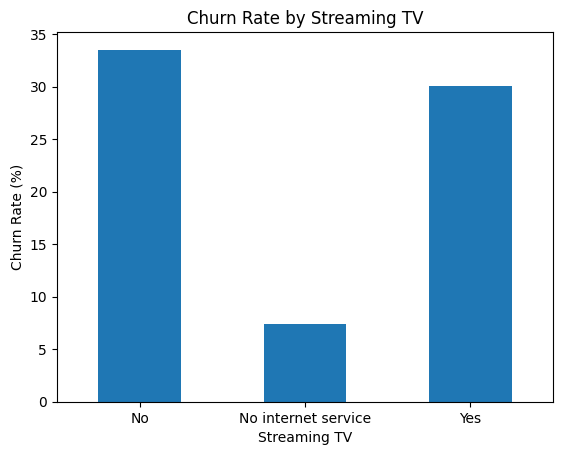

In [23]:
streamingtv_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [24]:
streamingmovies_churn = pd.crosstab(
      df["StreamingMovies"],
          df["Churn"],
              normalize="index"
              ) * 100

streamingmovies_churn


Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


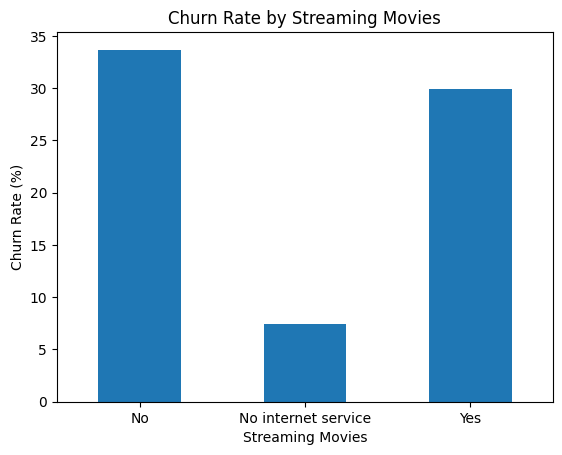

In [25]:
streamingmovies_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [26]:
paperless_churn = pd.crosstab(
      df["PaperlessBilling"],
          df["Churn"],
              normalize="index"
              ) * 100

paperless_churn


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


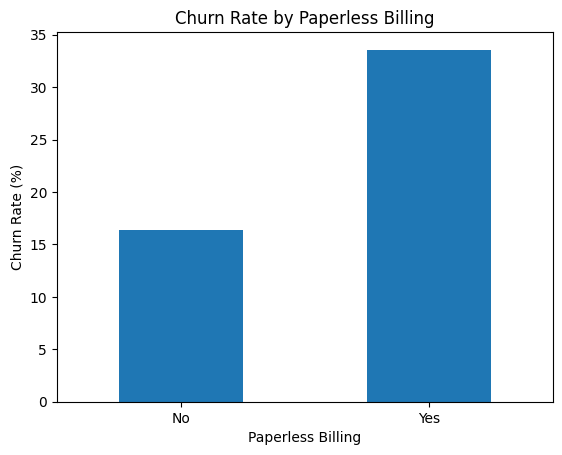

In [27]:
paperless_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [28]:
multiplelines_churn = pd.crosstab(
      df["MultipleLines"],
          df["Churn"],
              normalize="index"
              ) * 100

multiplelines_churn


Churn,No,Yes
MultipleLines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


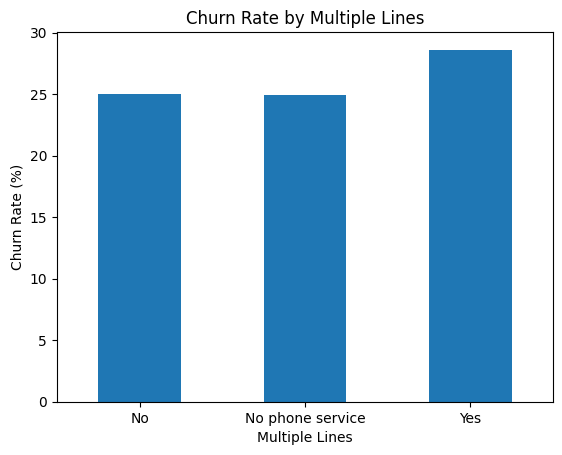

In [29]:
multiplelines_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [30]:
security_churn = pd.crosstab(
      df["OnlineSecurity"],
          df["Churn"],
              normalize="index"
              ) * 100

security_churn


Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


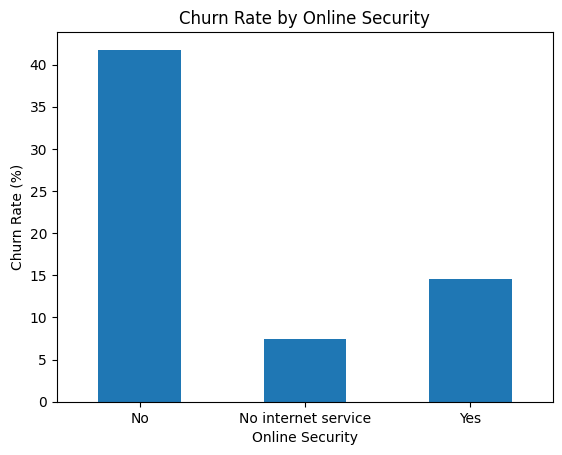

In [31]:
security_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [32]:
backup_churn = pd.crosstab(
      df["OnlineBackup"],
          df["Churn"],
              normalize="index"
              ) * 100

backup_churn


Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


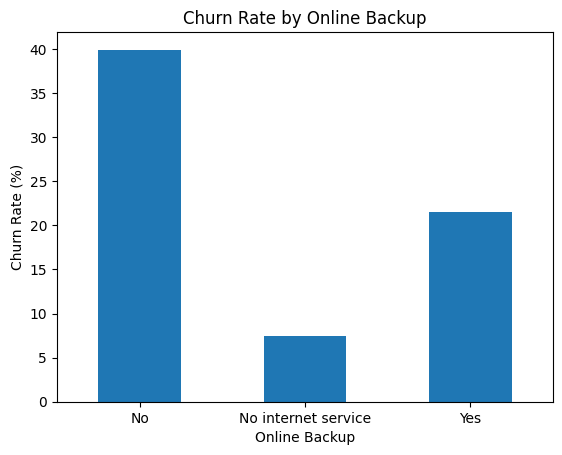

In [33]:
backup_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [34]:
device_churn = pd.crosstab(
      df["DeviceProtection"],
          df["Churn"],
              normalize="index"
              ) * 100

device_churn


Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


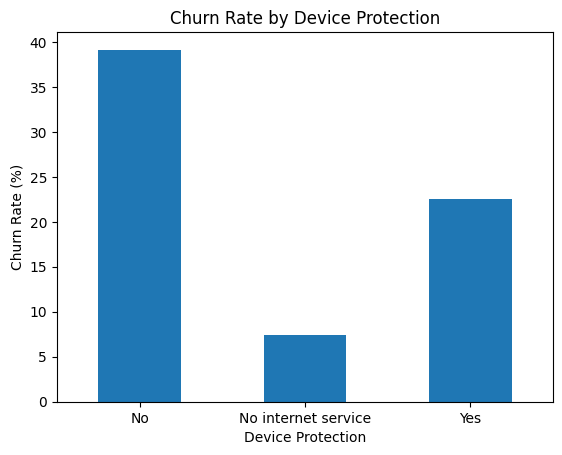

In [35]:
device_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [36]:
tech_churn = pd.crosstab(
      df["TechSupport"],
          df["Churn"],
              normalize="index"
              ) * 100

tech_churn


Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


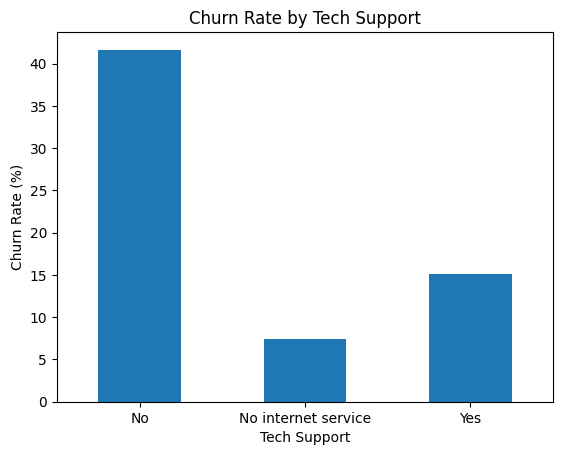

In [37]:
tech_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [38]:
streamingtv_churn = pd.crosstab(
      df["StreamingTV"],
          df["Churn"],
              normalize="index"
              ) * 100

streamingtv_churn


Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


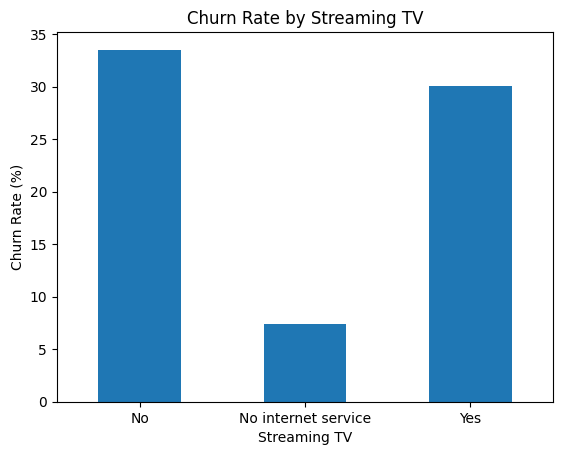

In [39]:
streamingtv_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [40]:
streamingmovies_churn = pd.crosstab(
      df["StreamingMovies"],
          df["Churn"],
              normalize="index"
              ) * 100

streamingmovies_churn


Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


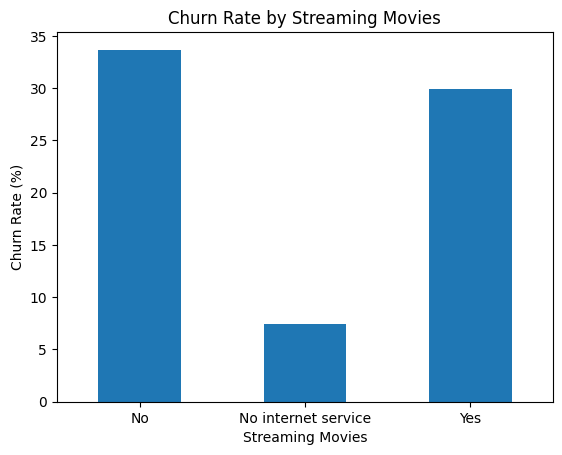

In [41]:
streamingmovies_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [42]:
paperless_churn = pd.crosstab(
      df["PaperlessBilling"],
          df["Churn"],
              normalize="index"
              ) * 100

paperless_churn


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


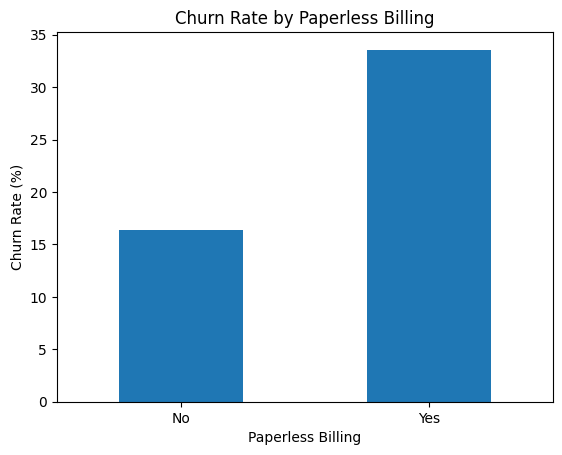

In [43]:
paperless_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [44]:
contract_churn = pd.crosstab(
      df["Contract"],
          df["Churn"],
              normalize="index"
              ) * 100

contract_churn


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


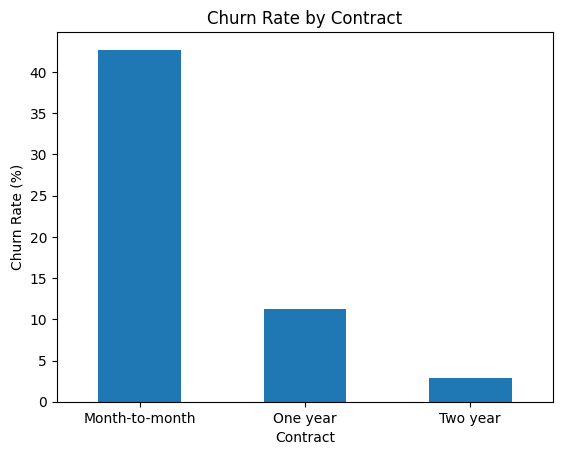

In [45]:
contract_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [46]:
payment_churn = pd.crosstab(
      df["PaymentMethod"],
          df["Churn"],
              normalize="index"
              ) * 100

payment_churn


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


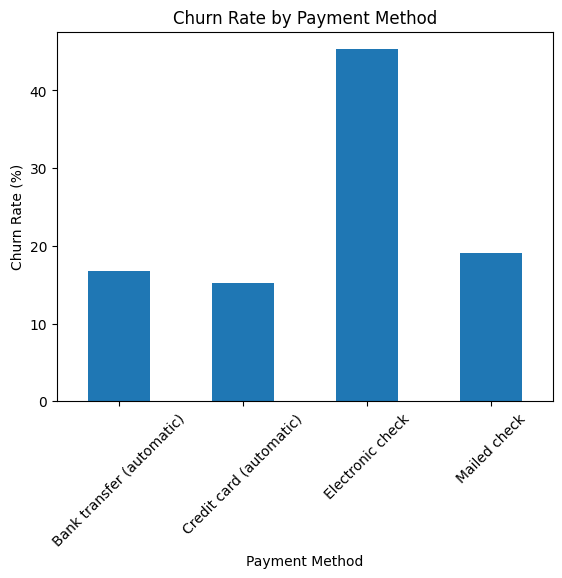

In [47]:
payment_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [48]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


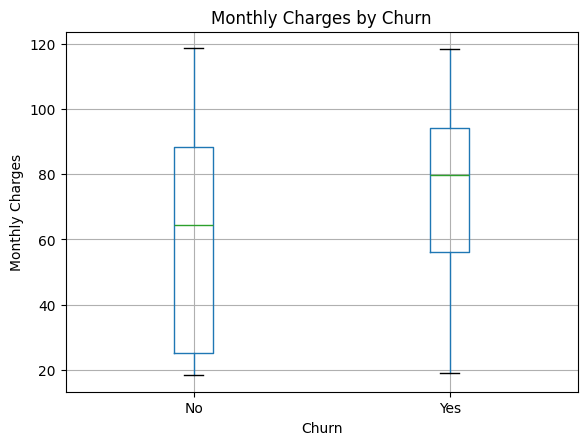

In [49]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [50]:
df.groupby("Churn")["TotalCharges"].describe()

,count,unique,top,freq
Churn,,,,
No,5174,4966,,11
Yes,1869,1732,20.2,6


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

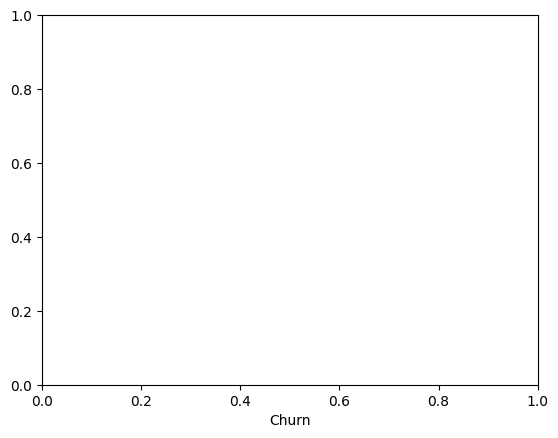

In [51]:
df.boxplot(column="TotalCharges", by="Churn")

plt.title("Total Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [54]:
df["TotalCharges"] = pd.to_numeric(
      df["TotalCharges"],
          errors="coerce"
          )


In [55]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [56]:
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


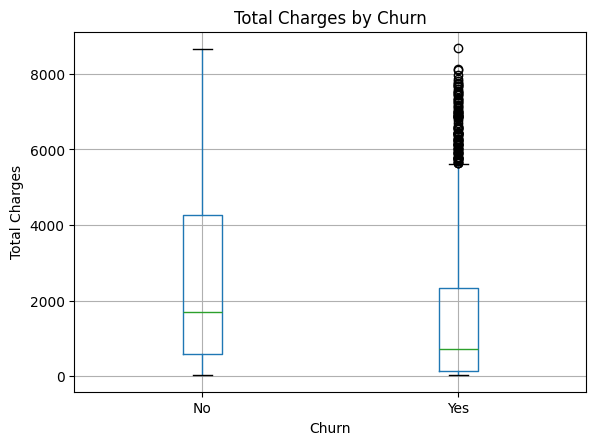

In [57]:
df.boxplot(column="TotalCharges", by="Churn")

plt.title("Total Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [58]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


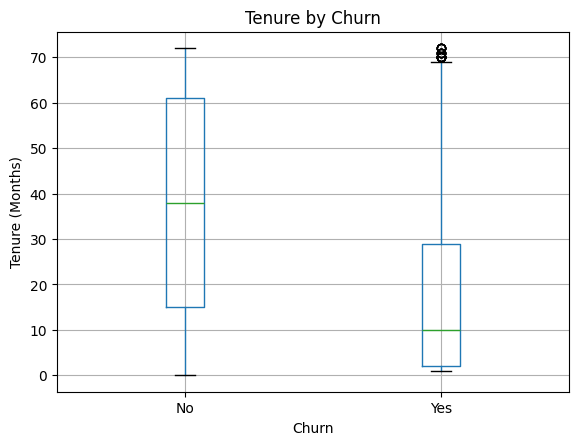

In [59]:
df.boxplot(column="tenure", by="Churn")

plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [60]:
senior_churn = pd.crosstab(
      df["SeniorCitizen"],
          df["Churn"],
              normalize="index"
              ) * 100

senior_churn


Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


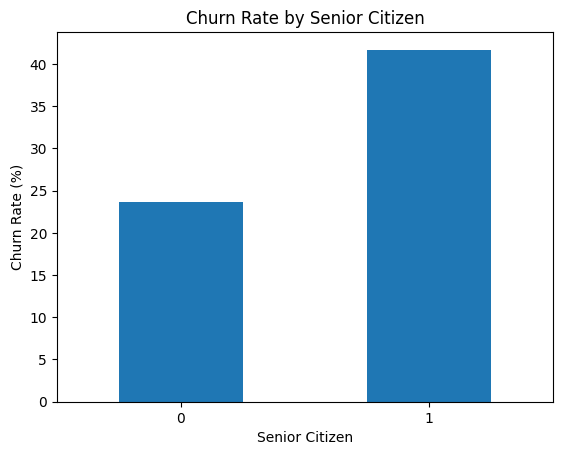

In [61]:
senior_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [63]:
gender_churn = pd.crosstab(
      df["gender"],
          df["Churn"],
              normalize="index"
              ) * 100

gender_churn


Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


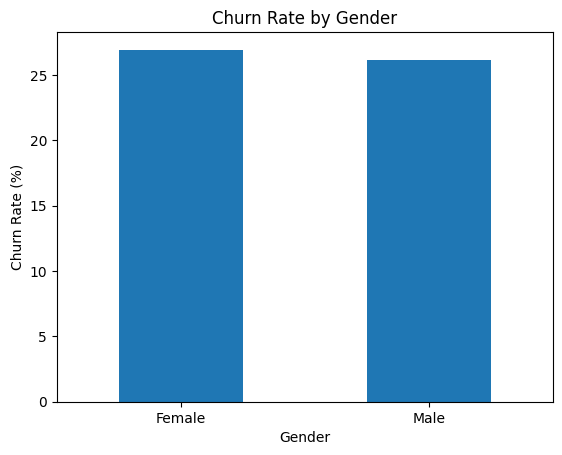

In [64]:
gender_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

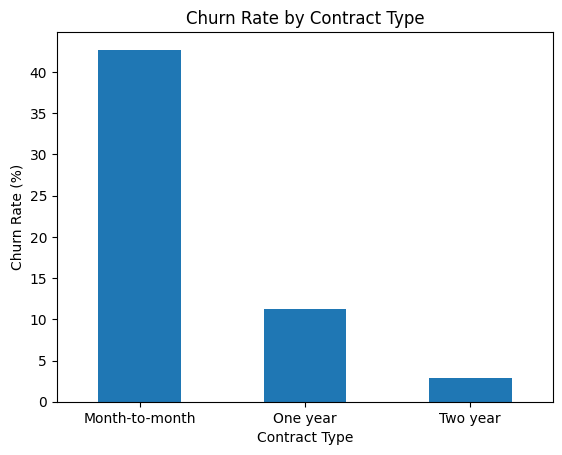

In [65]:
contract_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [66]:
total_customers = df["customerID"].nunique()
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = (churned_customers / total_customers) * 100
avg_monthly_charges = df["MonthlyCharges"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Overall Churn Rate:", round(churn_rate, 2), "%")
print("Average Monthly Charges:", round(avg_monthly_charges, 2))

Total Customers: 7043
Churned Customers: 1869
Overall Churn Rate: 26.54 %
Average Monthly Charges: 64.76


In [67]:
internet_churn = pd.crosstab(
      df["InternetService"],
          df["Churn"],
              normalize="index"
              ) * 100

internet_churn


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


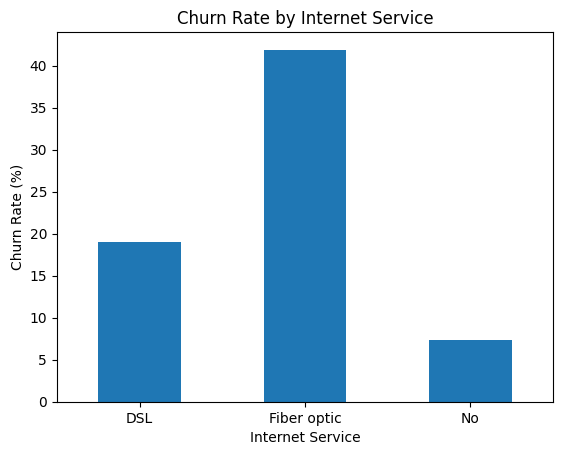

In [68]:
internet_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [69]:
df["TenureGroup"] = pd.cut(
      df["tenure"],
          bins=[0, 12, 24, 48, 72],
              labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"]
              )

tenure_churn = pd.crosstab(
                  df["TenureGroup"],
                      df["Churn"],
                          normalize="index"
                          ) * 100

tenure_churn


Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


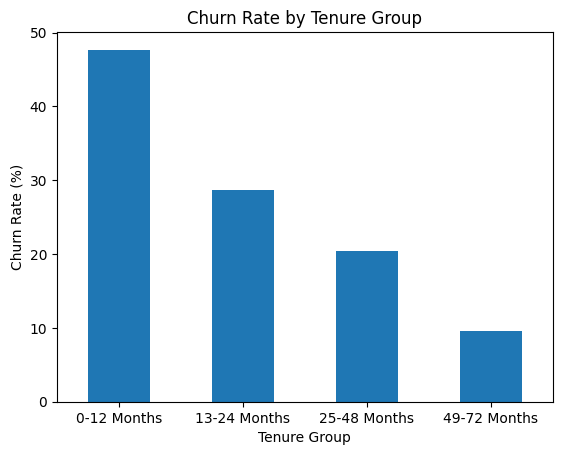

In [70]:
tenure_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [71]:
df.groupby("TenureGroup")["MonthlyCharges"].mean()

/tmp/ipykernel_1565/2502966398.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("TenureGroup")["MonthlyCharges"].mean()


,MonthlyCharges
TenureGroup,
0-12 Months,56.172023
13-24 Months,61.357275
25-48 Months,65.930552
49-72 Months,73.945377


/tmp/ipykernel_1565/2564620100.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("TenureGroup")["MonthlyCharges"].mean().plot(kind="bar")


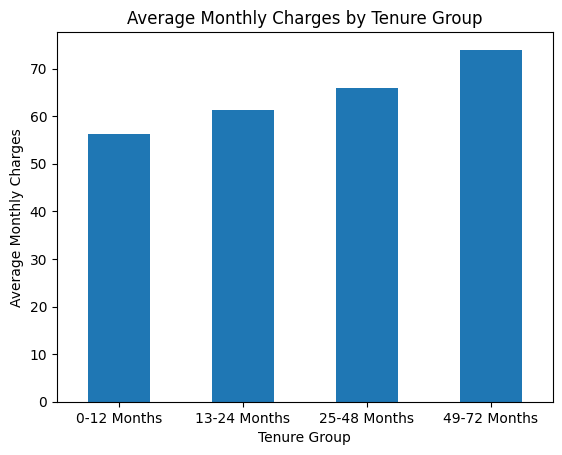

In [72]:
df.groupby("TenureGroup")["MonthlyCharges"].mean().plot(kind="bar")

plt.title("Average Monthly Charges by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

In [73]:
high_risk = df[
      (df["Contract"] == "Month-to-month") &
          (df["TenureGroup"] == "0-12 Months") &
              (df["TechSupport"] == "No") &
                  (df["OnlineSecurity"] == "No")
                  ]
print("High-Risk Customer Count:", high_risk["customerID"].nunique())
print("High-Risk Churn Rate:",
                        round((high_risk["Churn"] == "Yes").mean() * 100, 2), "%")

High-Risk Customer Count: 1188
High-Risk Churn Rate: 64.48 %


In [75]:
df.to_csv("/content/customer_churn_cleaned.csv", index=False)

In [76]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
